<a href="https://colab.research.google.com/github/alimasumajja/RegresiLinear_Kelas5B_Kelompok1/blob/main/RegresiLinear_5B_Kelompok1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Tahap EDA**

In [8]:
# 1. Install library kaggle (biasanya sudah ada di Colab, tapi untuk memastikan)
!pip install -q kaggle

In [9]:
# 2. Mengatur Environment Variable untuk API Token
import os
import getpass

print("masukkan token")
# getpass digunakan agar token yang Anda ketik tidak terlihat di layar
kaggle_token = getpass.getpass('KAGGLE_API_TOKEN: ')

# Menyetel environment variable agar library kaggle bisa membacanya
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("\nOtentikasi API Kaggle Selesai!")

masukkan token
KAGGLE_API_TOKEN: ··········

Otentikasi API Kaggle Selesai!


In [10]:
# ---------------------------------------------------------
# 3. MENGUNDUH DATASET CONTOH
# Perintah: kaggle datasets download -d [nama-pemilik/nama-dataset]
# ---------------------------------------------------------
print("Mengunduh dataset Melbourne Housing...")
!kaggle datasets download -d anthonypino/melbourne-housing-market

Mengunduh dataset Melbourne Housing...
Dataset URL: https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market
License(s): CC-BY-NC-SA-4.0
melbourne-housing-market.zip: Skipping, found more recently modified local copy (use --force to force download)


In [11]:
# 4. Mengekstrak file ZIP hasil unduhan
# -q artinya 'quiet' (tanpa log ekstraksi yang panjang)
!unzip -o melbourne-housing-market.zip -d /content/

print("Unduhan dan Ekstraksi Selesai!")

Archive:  melbourne-housing-market.zip
  inflating: /content/MELBOURNE_HOUSE_PRICES_LESS.csv  
  inflating: /content/Melbourne_housing_FULL.csv  
Unduhan dan Ekstraksi Selesai!


In [12]:
# ---------------------------------------------------------
# 5. MEMUAT DATA KE PANDAS (Langkah Awal EDA)
# ---------------------------------------------------------
import pandas as pd

# Membaca file CSV yang sudah diekstrak
# Sesuaikan nama file CSV dengan isi dari ZIP tersebut
df = pd.read_csv('/content/melb_data.csv')

In [13]:
# Menampilkan 5 baris pertama untuk memastikan koneksi dan load data berhasil
print("\n--- 5 Baris Pertama Dataset Melbourne Housing ---")
display(df.head())


--- 5 Baris Pertama Dataset Melbourne Housing ---


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## **Inspeksi Awal Data (Initial Data Inspection)**

### **Tujuan Skrip**

Skrip ini bertujuan untuk melakukan langkah-langkah awal dalam analisis data pada dataset Melbourne Housing. Secara spesifik, skrip ini meliputi:

1. Pengaturan Lingkungan: Memastikan library Kaggle terinstal dan mengonfigurasi token API Kaggle untuk memungkinkan akses terhadap dataset.
2. Pengunduhan dan Ekstraksi Data: Mengunduh dataset Melbourne Housing dari Kaggle dan mengekstraknya sehingga file dataset dapat digunakan dalam proses analisis.
3. Pemuatan Data: Memuat data dari file CSV melb_data.csv ke dalam Pandas DataFrame untuk memudahkan proses manipulasi, pemeriksaan, dan analisis data.
4. Inspeksi Awal Data (Initial Data Inspection): Melakukan pemeriksaan awal terhadap struktur dataset, meliputi melihat beberapa baris pertama dan terakhir, mengetahui dimensi dataset (jumlah baris dan kolom), memeriksa tipe data setiap kolom, serta mendapatkan daftar nama kolom. Langkah ini dilakukan untuk memahami karakteristik dasar dataset sebelum melanjutkan ke tahap Exploratory Data Analysis (EDA) dan proses analisis selanjutnya.

In [14]:
# Tampilkan 5 baris pertama data
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Tampilkan 5 baris terakhir data (opsional, untuk memastikan data dimuat utuh)
print("\n--- 5 Baris Terakhir Data ---")
display(df.tail())

# Cek dimensi data (jumlah baris dan kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Cek tipe data setiap kolom dan informasi penggunaan memori
print("\n--- Informasi Dataset (Tipe Data & Non-Null) ---")
df.info()

# Dapatkan nama-nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())

--- 5 Baris Pertama Data ---


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0



--- 5 Baris Terakhir Data ---


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0
13579,Yarraville,6 Agnes St,4,h,1285000.0,SP,Village,26/08/2017,6.3,3013.0,...,1.0,1.0,362.0,112.0,1920.0,NaN,-37.81188,144.88449,Western Metropolitan,6543.0



Dimensi dataset: 13580 baris, 21 kolom

--- Informasi Dataset (Tipe Data & Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  Coun

### **Penjelasan Bagian-bagian Penting Skrip**

Skrip ini terbagi menjadi beberapa bagian penting yang bekerja secara berurutan untuk melakukan analisis dan pemodelan data pada dataset Melbourne Housing:

1. Instalasi dan Konfigurasi
Kaggle API: Bagian awal digunakan untuk mempersiapkan lingkungan agar dapat berinteraksi dengan Kaggle. Library kaggle diinstal menggunakan !pip install -q kaggle. Selanjutnya, os dan getpass digunakan untuk memasukkan serta menyimpan token API Kaggle melalui environment variable sehingga proses autentikasi dapat dilakukan dengan lebih aman.
2. Pengunduhan dan Ekstraksi Dataset: Skrip kemudian menjalankan perintah Kaggle untuk mengunduh dataset. File yang diperoleh dalam bentuk ZIP kemudian diekstrak menggunakan perintah unzip agar data dapat digunakan dalam proses analisis.
3. Pemuatan Data ke Pandas DataFrame: Dataset Melbourne Housing dimuat menggunakan pd.read_csv('/content/melb_data.csv'). Data tersebut disimpan dalam variabel df yang berbentuk DataFrame Pandas sehingga dapat diproses dan dianalisis menggunakan berbagai fungsi Pandas.
4. Inspeksi Awal Data: Setelah data dimuat, dilakukan pemeriksaan awal menggunakan df.head() untuk melihat lima baris pertama dan df.tail() untuk melihat lima baris terakhir. Selanjutnya, df.shape digunakan untuk mengetahui jumlah baris dan kolom, df.info() digunakan untuk melihat tipe data serta jumlah data yang tersedia pada setiap kolom, sedangkan df.columns.tolist() digunakan untuk menampilkan daftar nama kolom. Tahap ini penting untuk memahami struktur awal dataset sebelum dilakukan analisis lebih lanjut.
5. Pengecekan Kualitas Data: Skrip melakukan pemeriksaan missing values menggunakan df.isnull().sum() dan menghitung persentasenya. Hasil pemeriksaan menunjukkan adanya missing values pada beberapa variabel, yaitu Car, BuildingArea, YearBuilt, dan CouncilArea. Selain itu, dibuat heatmap missing values untuk melihat pola persebaran data yang hilang. Skrip juga memeriksa data duplikat menggunakan df.duplicated().sum().
6. Statistik Deskriptif: Fungsi df.describe() digunakan untuk memperoleh statistik deskriptif dari variabel numerik, seperti count, mean, standard deviation, nilai minimum, kuartil, median, dan maksimum. Sementara itu, df.describe(include='object') digunakan untuk melihat karakteristik variabel kategorikal, seperti jumlah kategori unik dan kategori yang paling sering muncul.
7. Analisis Univariat: Data numerik dianalisis menggunakan histogram dengan KDE untuk melihat distribusi data serta boxplot untuk mendeteksi kemungkinan outlier. Untuk data kategorikal digunakan countplot untuk melihat frekuensi masing-masing kategori.
8. Analisis Bivariat dan Multivariat: Hubungan antarvariabel numerik dianalisis menggunakan heatmap korelasi. Selain itu, digunakan scatter plot untuk melihat hubungan antara Rooms dengan Price serta Landsize dengan Price berdasarkan tipe rumah. Boxplot juga digunakan untuk membandingkan distribusi Price berdasarkan Type dan Method.

## **Pengecekan Kualitas Data Dasar** (Basic Data Quality Checks)

--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)
Car,62,0.456554
BuildingArea,6450,47.496318
YearBuilt,5375,39.580265
CouncilArea,1369,10.081001


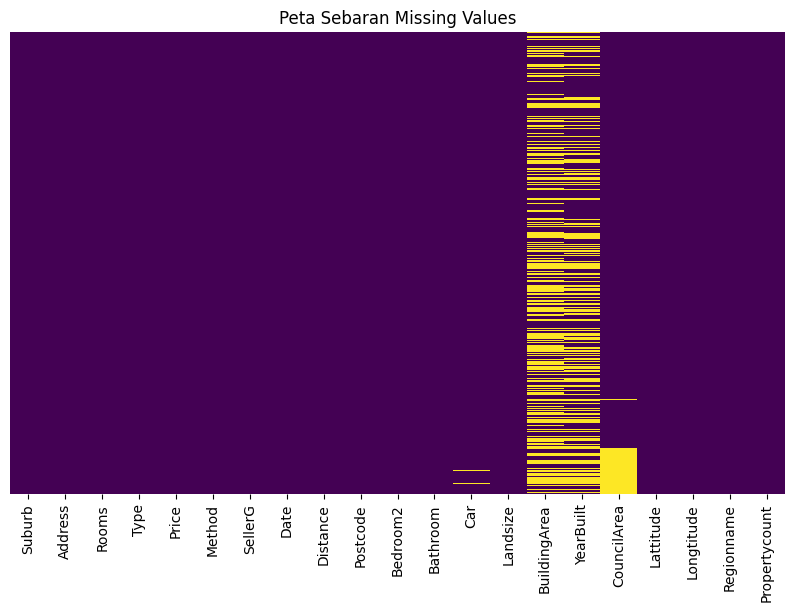


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 0


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Jumlah Missing', 'Persentase (%)'])
# Tampilkan hanya kolom yang memiliki missing value
display(missing_table[missing_table['Jumlah Missing'] > 0])

# Visualisasi Missing Values (Menggunakan Heatmap seaborn)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Peta Sebaran Missing Values')
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")
# Jika ada, Anda bisa menampilkan contoh duplikatnya dengan mengaktifkan baris di bawah:
# if jumlah_duplikat > 0:
#     display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

### **Ringkasan Pengecekan Kualitas Data**

Berdasarkan pemeriksaan kualitas data yang telah dilakukan, ditemukan missing values pada beberapa kolom. Kolom yang memiliki nilai hilang antara lain:

*   Car sebanyak 62 data (0,46%).
*   BuildingArea sebanyak 6.450 data (47,50%).
*   YearBuilt sebanyak 5.375 data (39,58%).
*   CouncilArea sebanyak 1.369 data (10,08%).

Missing values terbanyak terdapat pada kolom BuildingArea dan YearBuilt, sehingga kedua kolom tersebut memerlukan perhatian lebih lanjut pada tahap data preprocessing.

Selain pemeriksaan missing values, dilakukan juga pemeriksaan terhadap data duplikat. Hasil pemeriksaan menunjukkan bahwa tidak terdapat baris data duplikat identik (0 duplikat).

Dengan demikian, dataset belum dapat dikatakan sepenuhnya bersih karena masih terdapat missing values. Penanganan terhadap missing values akan dilakukan pada tahap data preprocessing, sebelum dataset digunakan dalam proses pemodelan regresi linear.

## **Statistik Deskriptif (Descriptive Statistics)**

In [16]:
print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df.describe())

print("\n--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---")
display(df.describe(include='object'))

--- Statistik Deskriptif untuk Kolom Numerik ---


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000



--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---


,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
count,13580,13580,13580,13580,13580,13580,12211,13580
unique,314,13378,3,5,268,58,33,8
top,Reservoir,5 Margaret St,h,S,Nelson,27/05/2017,Moreland,Southern Metropolitan
freq,359,3,9449,9022,1565,473,1163,4695


### **Ringkasan Statistik Deskriptif**

Setelah dilakukan analisis statistik deskriptif pada dataset Melbourne Housing, diperoleh gambaran mengenai karakteristik variabel numerik dan kategorikal yang terdapat dalam dataset.

Untuk kolom numerik, terdapat beberapa variabel seperti Rooms, Price, Distance, Postcode, Bedroom2, Bathroom, Car, Landsize, BuildingArea, YearBuilt, Latitude, Longitude, dan Propertycount.

* Count: Sebagian besar variabel memiliki 13.580 data. Namun, terdapat beberapa variabel yang memiliki data lebih sedikit karena adanya missing values, yaitu Car sebanyak 13.518 data, BuildingArea sebanyak 7.130 data, dan YearBuilt sebanyak 8.205 data.
* Price: Harga properti memiliki rata-rata sekitar 1,076 juta, dengan median sebesar 930 ribu. Nilai minimum adalah 85 ribu, sedangkan nilai maksimum mencapai 9 juta. Perbedaan antara mean dan median menunjukkan bahwa distribusi harga cenderung menceng ke kanan (right-skewed), dengan adanya beberapa properti yang memiliki harga sangat tinggi.
* Rooms: Jumlah kamar memiliki rata-rata sekitar 2,94 kamar, dengan median 3 kamar. Nilai minimum adalah 1 dan maksimum 10 kamar.
* Distance: Jarak properti memiliki rata-rata sekitar 10,14, dengan nilai minimum 0 dan maksimum 48,1.
* Landsize: Luas tanah memiliki rata-rata sekitar 558,42, median 440, dan nilai maksimum mencapai 433.014. Perbedaan yang sangat besar antara median dan maksimum menunjukkan adanya beberapa nilai yang sangat tinggi dan berpotensi menjadi outlier.
* BuildingArea: Luas bangunan memiliki rata-rata sekitar 151,97, median 126, dengan nilai maksimum 44.515. Variasi yang cukup besar terlihat dari standar deviasi sebesar 541,01.
* YearBuilt: Tahun pembangunan memiliki rata-rata sekitar 1964,68, dengan median 1970. Tahun pembangunan paling lama adalah 1196, sedangkan yang terbaru 2018.Nilai minimum yang sangat jauh dari sebagian besar tahun pembangunan menunjukkan adanya nilai yang perlu diperiksa lebih lanjut.
* Bathroom: Jumlah kamar mandi memiliki rata-rata 1,53, dengan median 1 dan maksimum 8.
* Bedroom2: Jumlah kamar tidur memiliki rata-rata 2,91, median 3, dan maksimum 20.
* Propertycount: Rata-rata jumlah properti sekitar 7.454, dengan nilai minimum 249 dan maksimum 21.650.

Untuk kolom kategorikal, hasil statistik menunjukkan:

* Suburb memiliki 314 kategori unik, dengan kategori yang paling sering muncul adalah Reservoir sebanyak 359 data.
* Address memiliki 13.378 kategori unik, menunjukkan bahwa sebagian besar alamat berbeda.
* Type memiliki 3 kategori, dengan kategori h sebagai kategori yang paling sering muncul sebanyak 9.449 data.
* Method memiliki 5 kategori, dengan kategori S sebagai yang paling sering muncul sebanyak 9.022 data.
* SellerG memiliki 268 kategori unik, dengan Nelson sebagai kategori yang paling sering muncul sebanyak 1.565 data.
* Date memiliki 58 kategori unik, dengan tanggal 27/05/2017 sebagai yang paling sering muncul sebanyak 473 data.
* CouncilArea memiliki 33 kategori unik dan 12.211 data, menunjukkan adanya missing values. Kategori yang paling sering muncul adalah Moreland sebanyak 1.163 data.
* Regionname memiliki 8 kategori unik, dengan Southern Metropolitan sebagai kategori yang paling sering muncul sebanyak 4.695 data.

Secara keseluruhan, statistik deskriptif menunjukkan bahwa dataset Melbourne Housing memiliki karakteristik properti yang cukup beragam, baik dari segi harga, jumlah kamar, luas tanah, luas bangunan, maupun lokasi. Selain itu, ditemukan adanya missing values pada beberapa variabel, khususnya BuildingArea, YearBuilt, Car, dan CouncilArea. Temuan ini akan menjadi pertimbangan pada tahap data preprocessing sebelum data digunakan untuk pemodelan regresi linear.

## **Analisis Univariat (Univariate Analysis)**

### Analisis Univariat untuk Kolom Numerik ###


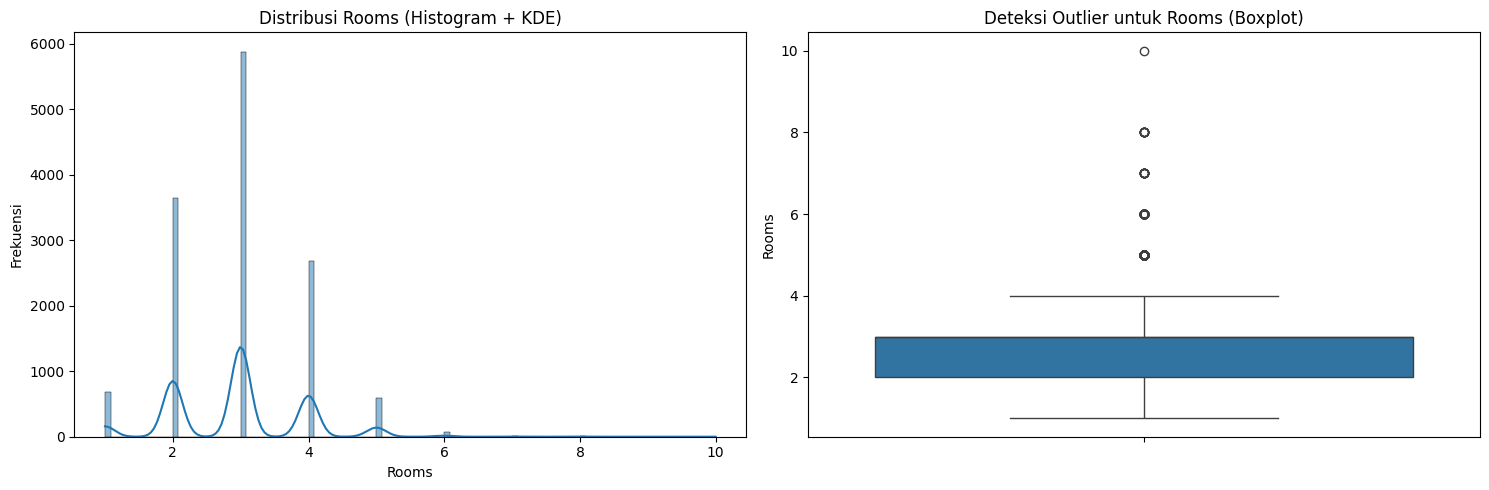

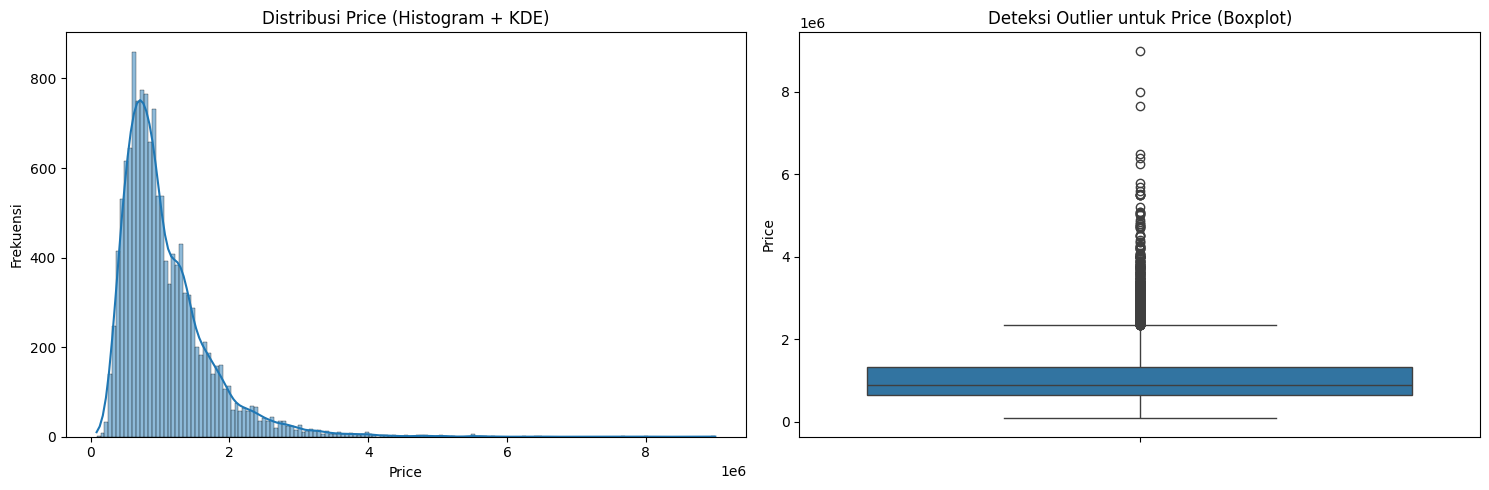

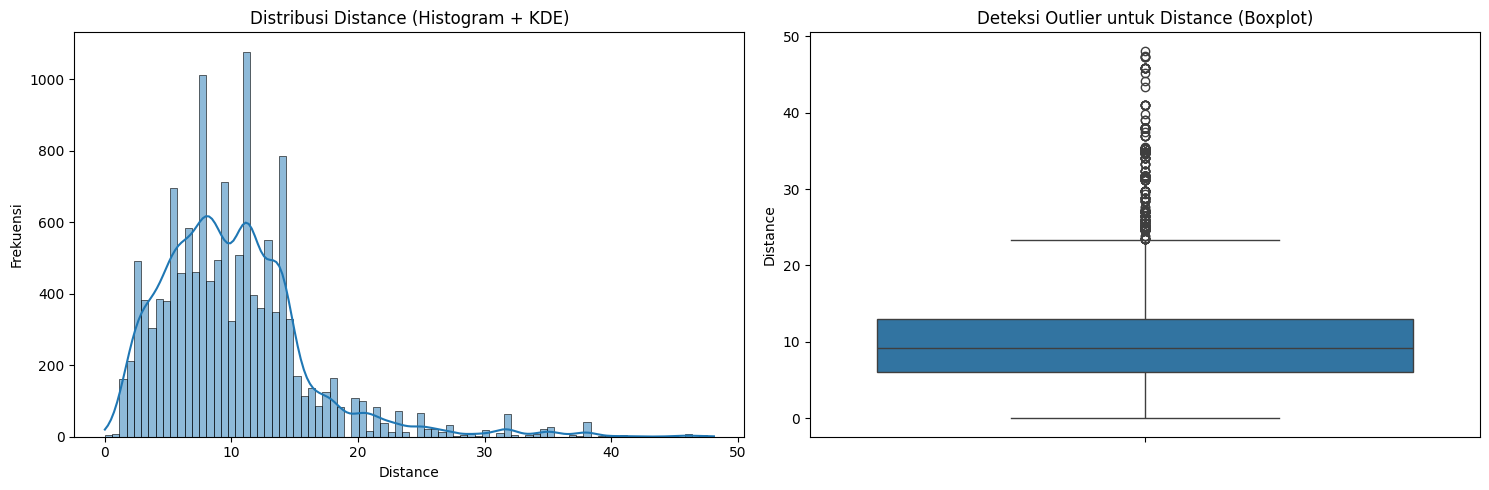

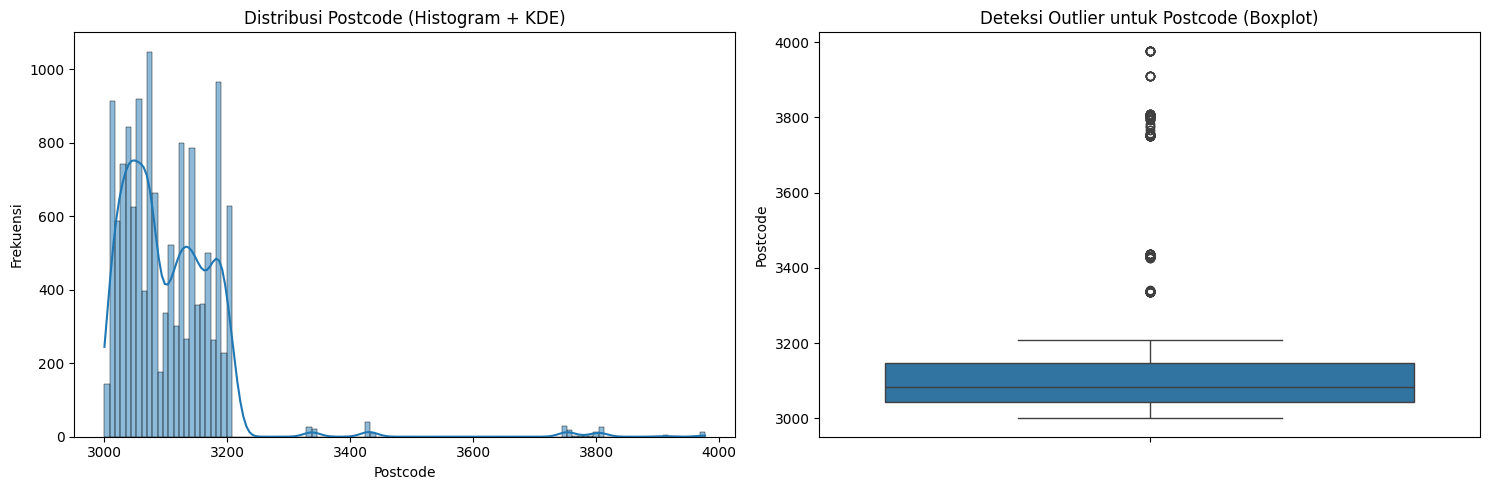

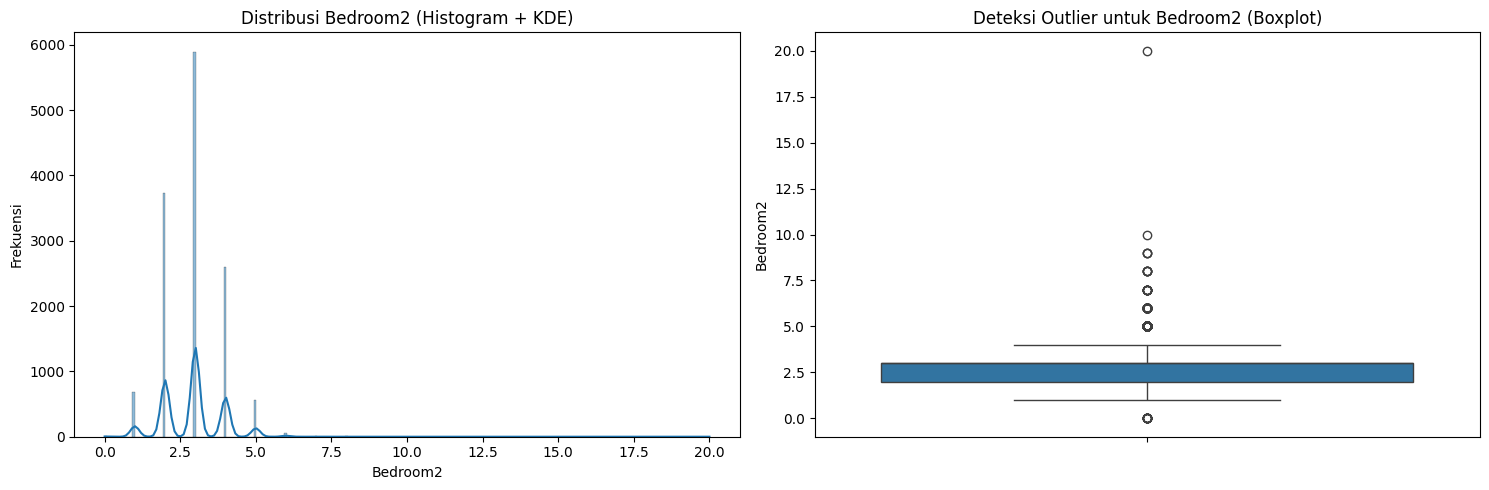

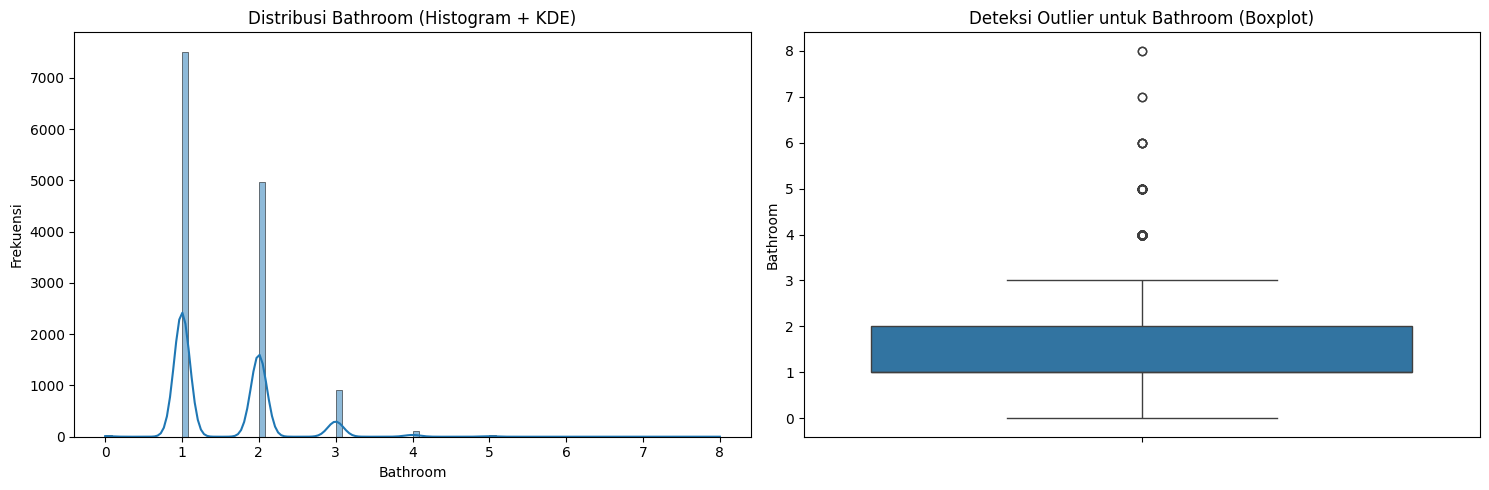

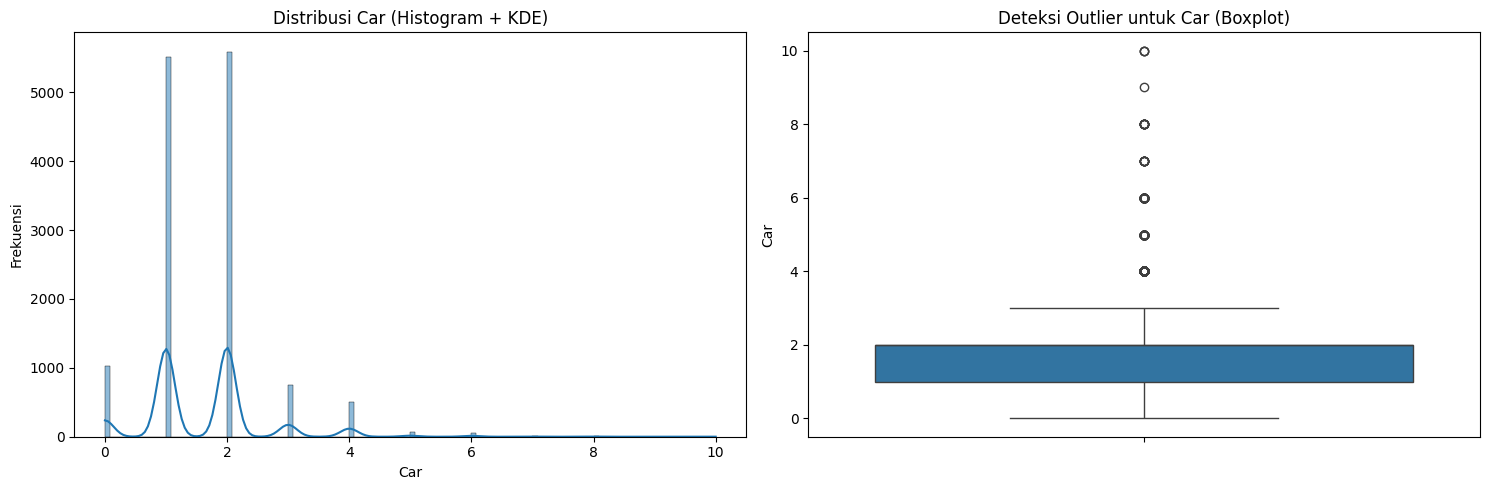

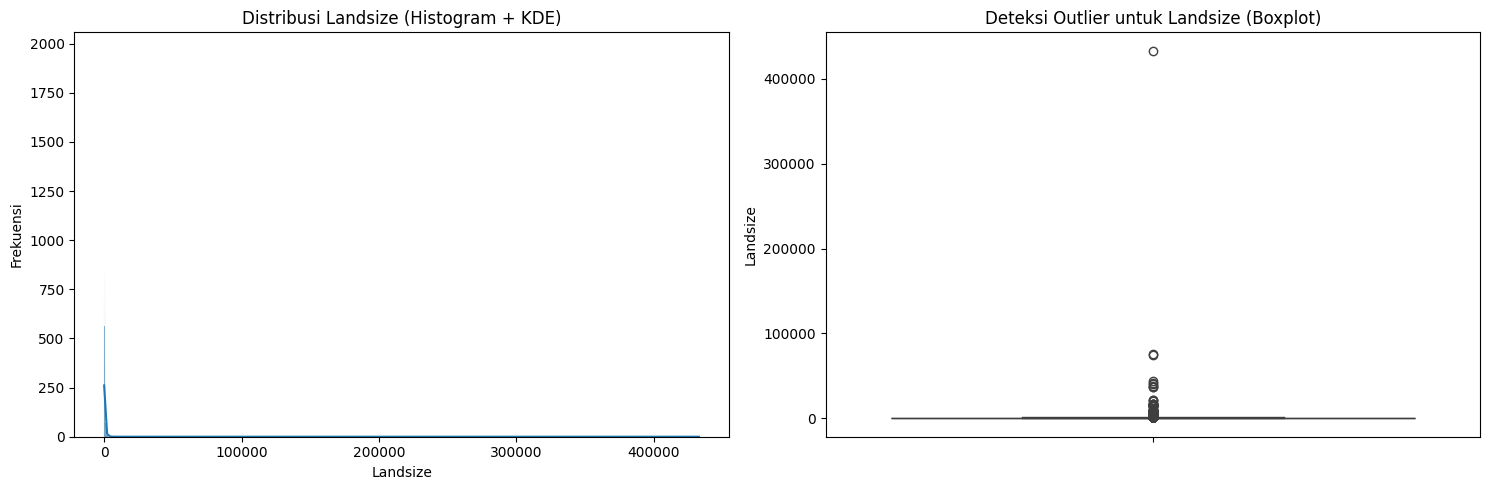

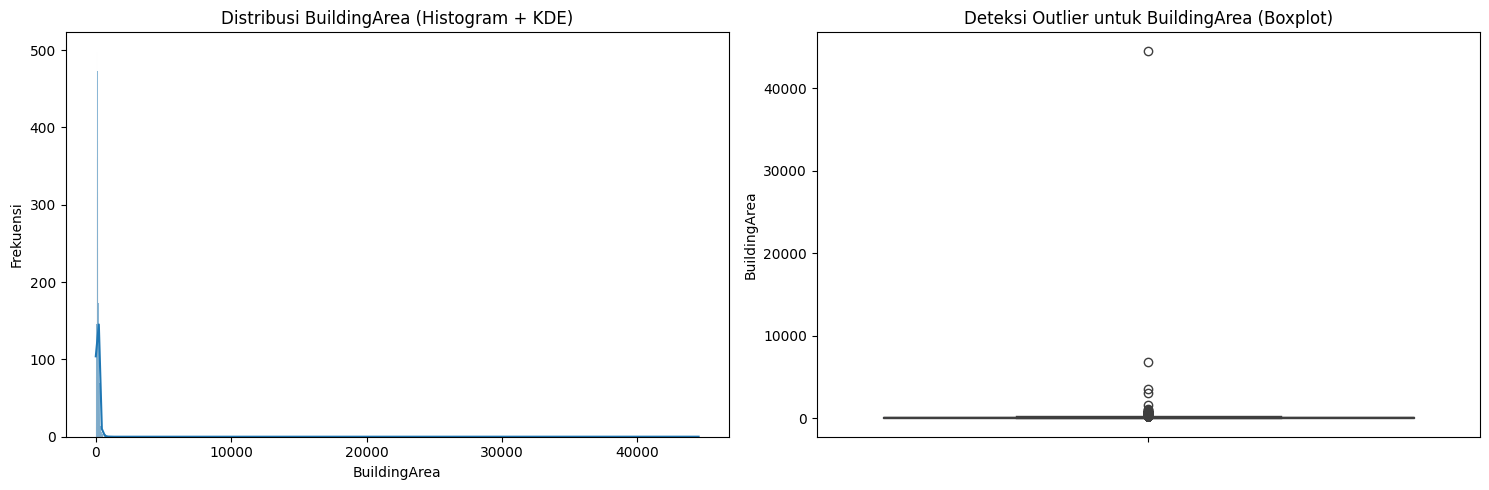

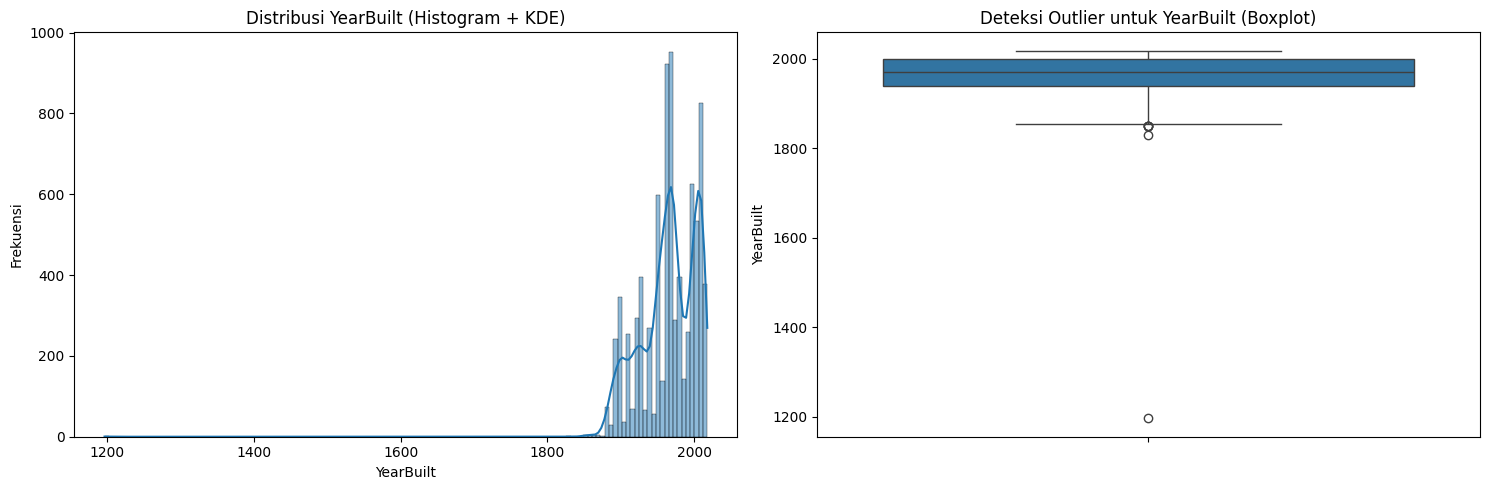

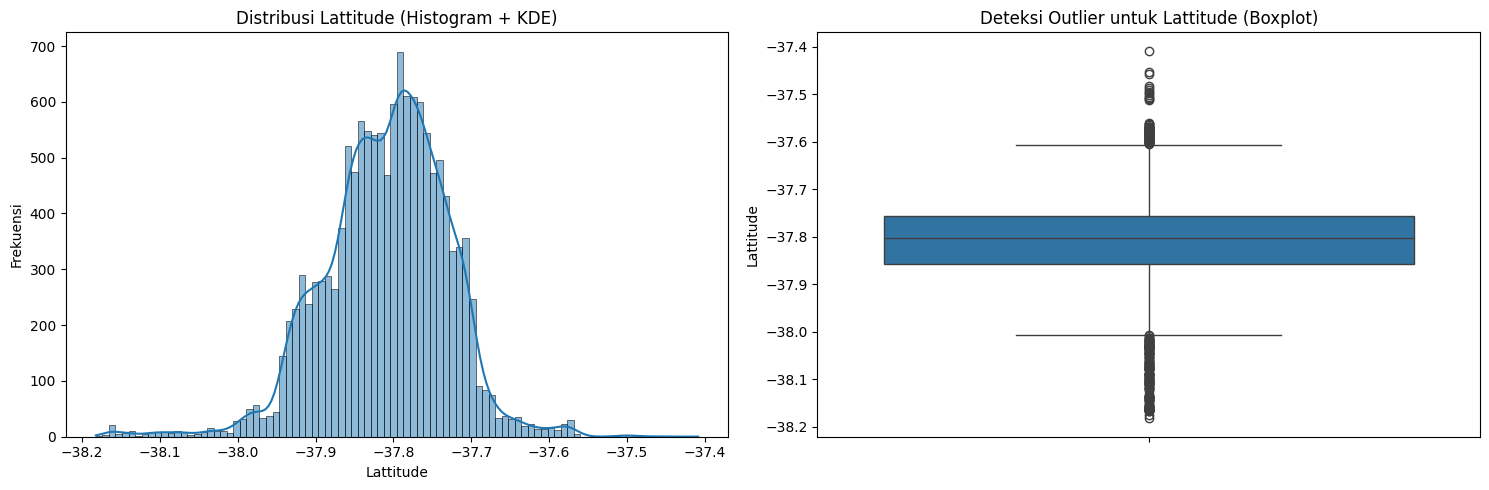

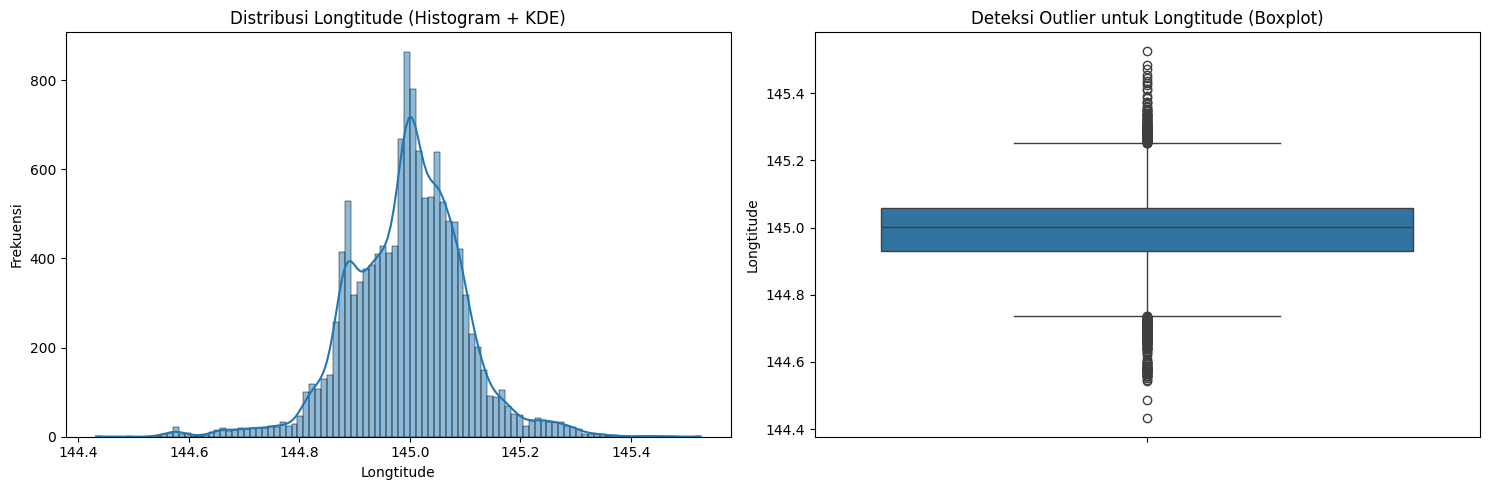

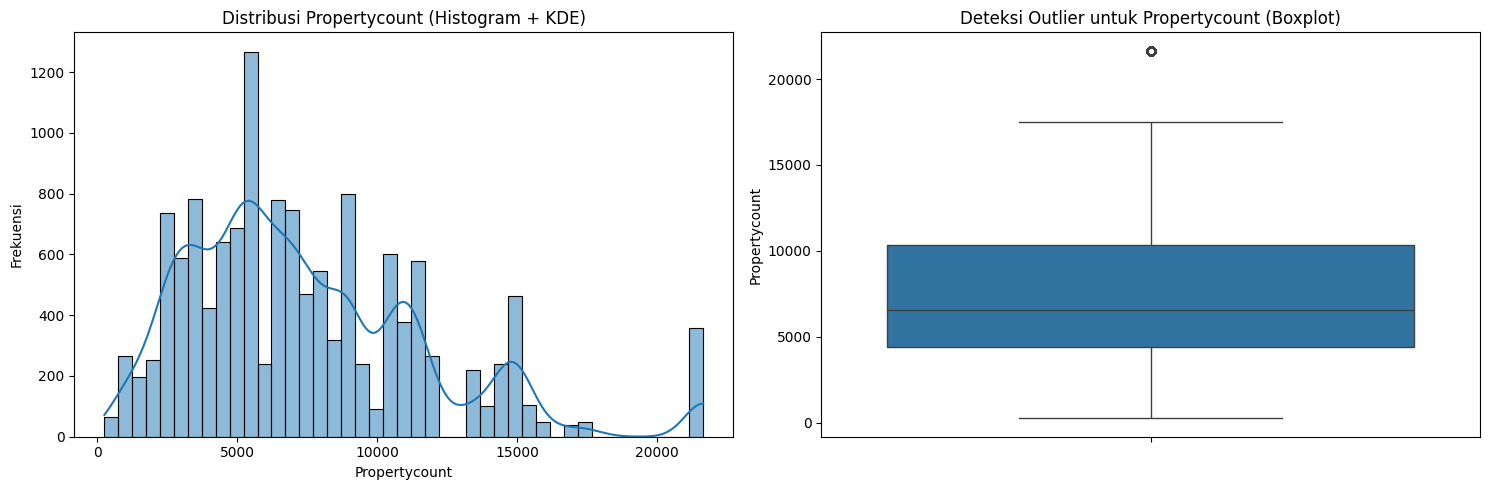


### Analisis Univariat untuk Kolom Kategorikal ###


/tmp/ipykernel_5210/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


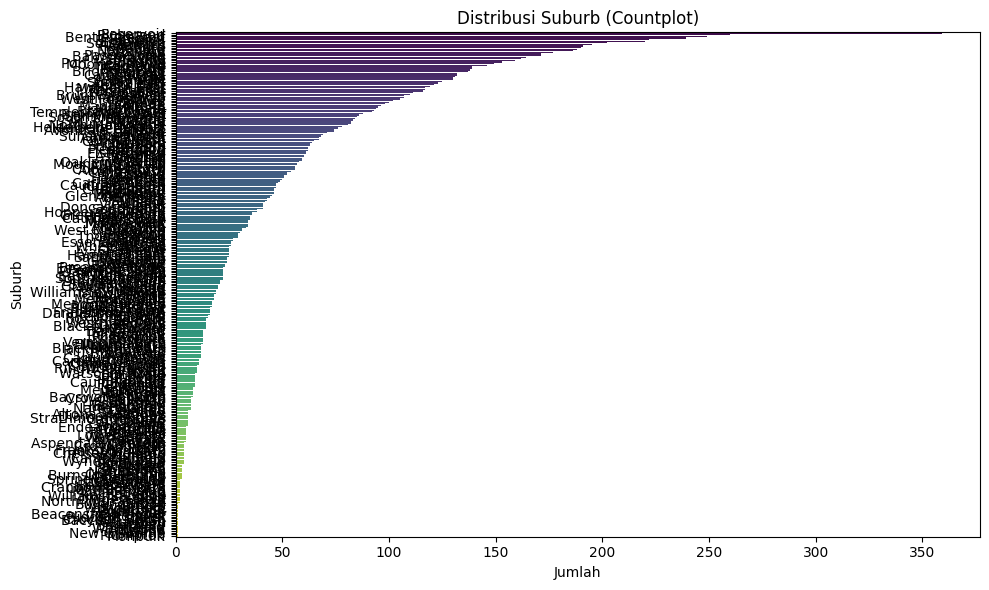

/tmp/ipykernel_5210/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


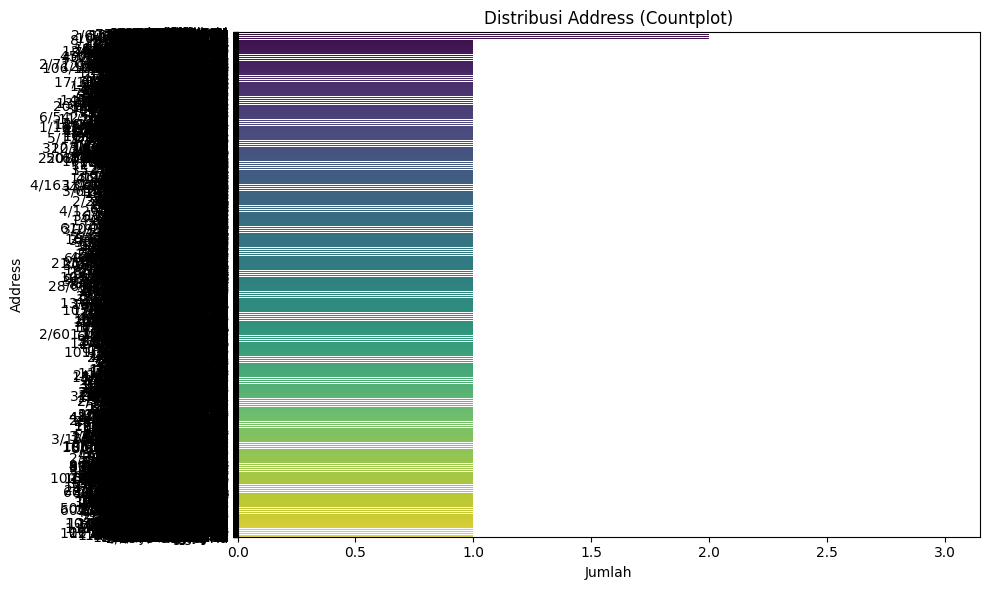

/tmp/ipykernel_5210/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


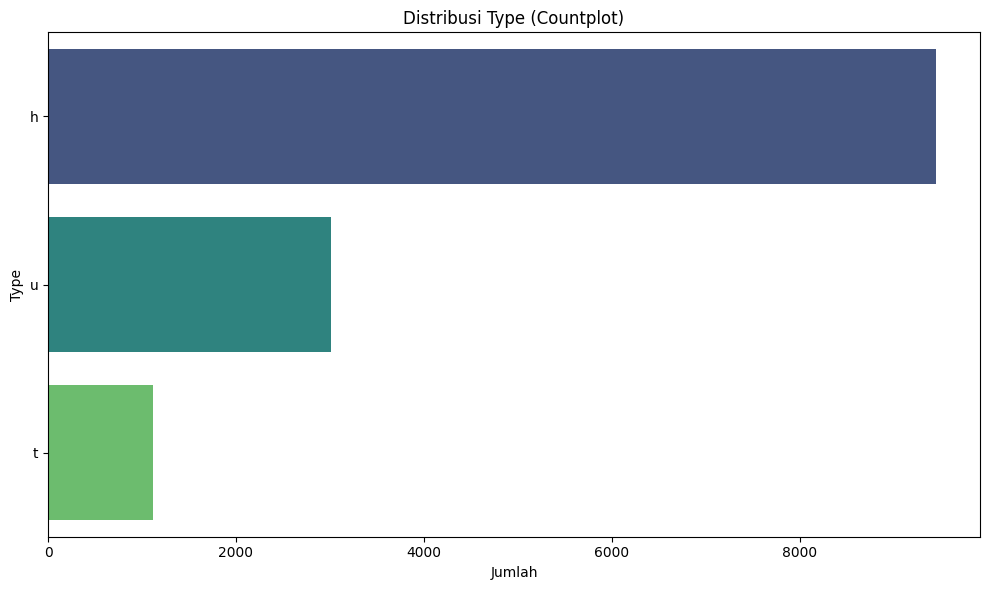

/tmp/ipykernel_5210/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


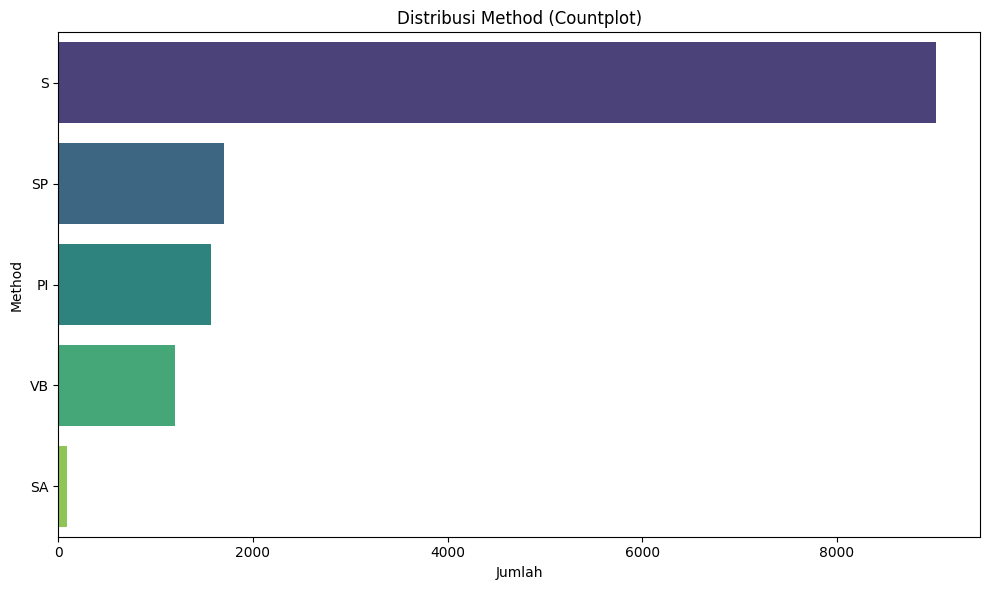

/tmp/ipykernel_5210/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


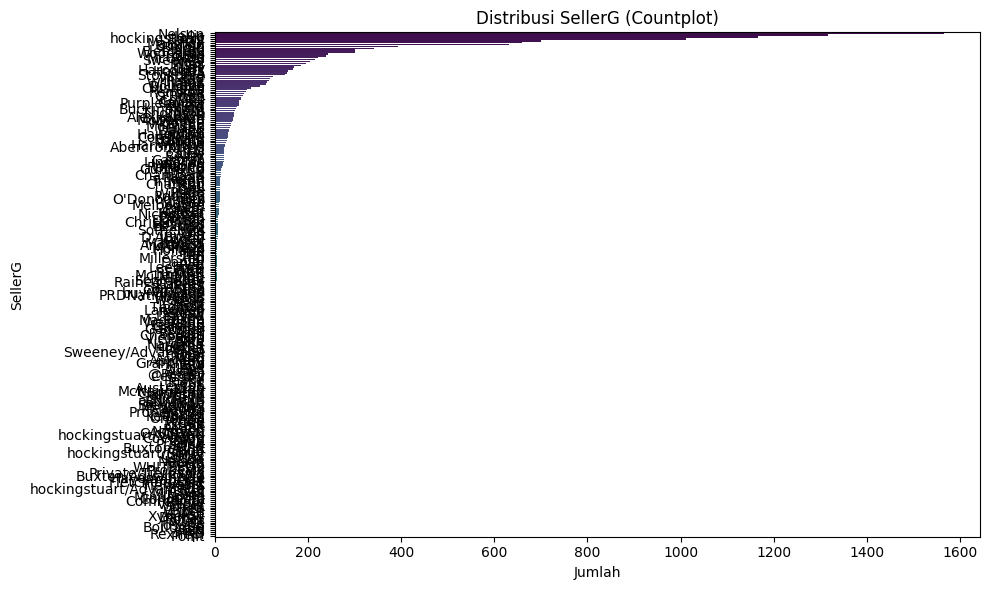

/tmp/ipykernel_5210/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


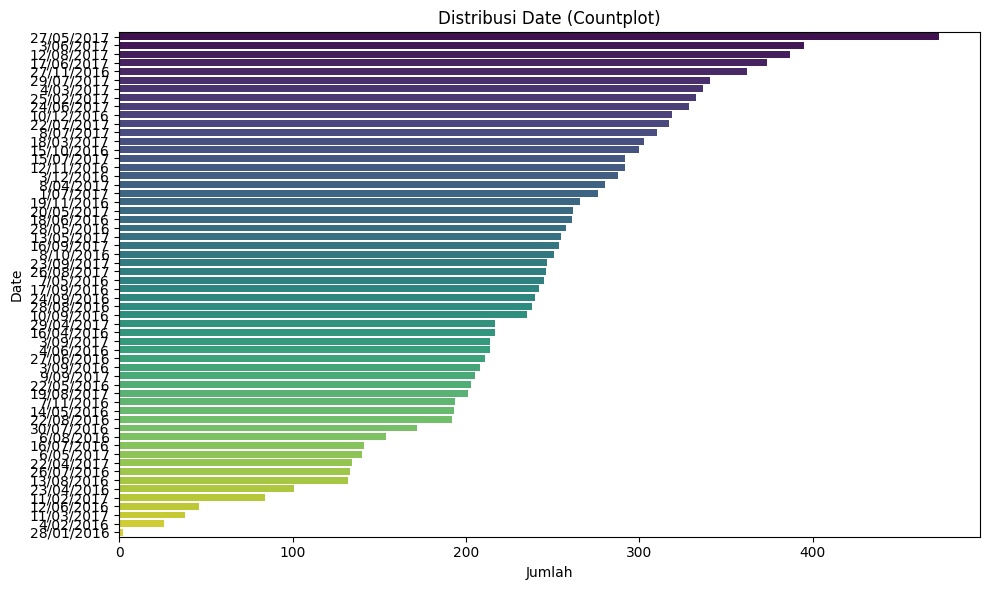

/tmp/ipykernel_5210/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


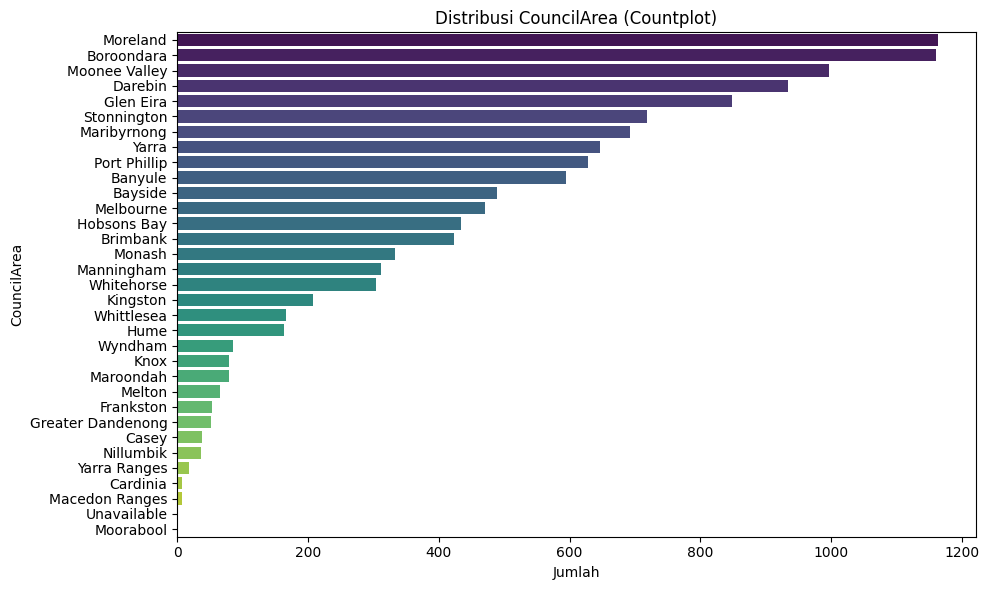

/tmp/ipykernel_5210/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


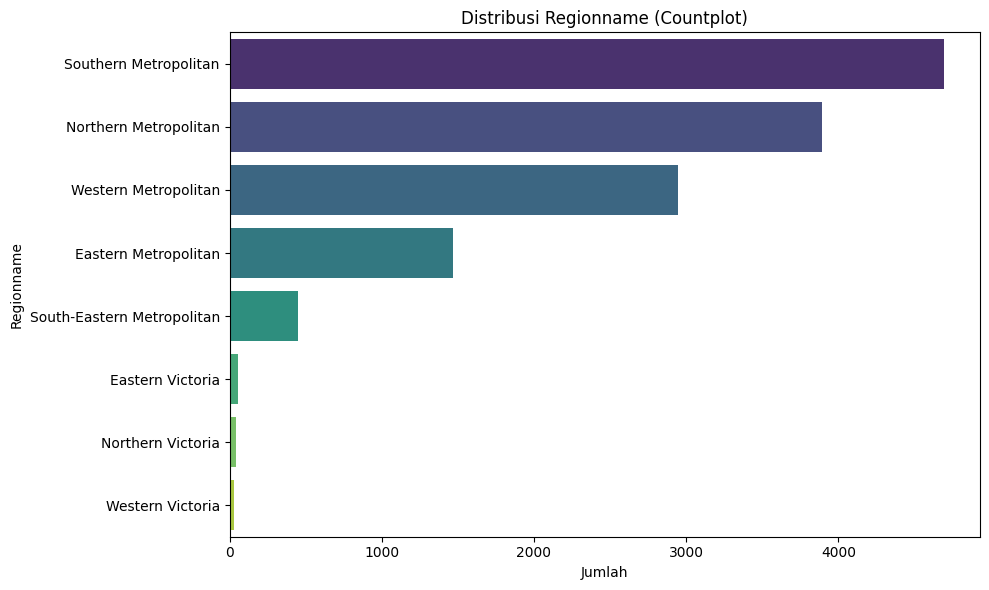

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### Analisis Univariat untuk Kolom Numerik ###")
for kolom in kolom_numerik:
    plt.figure(figsize=(15, 5))

    # Histplot dengan KDE
    plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom} (Histogram + KDE)')
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')

    # Boxplot untuk Outliers
    plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
    sns.boxplot(y=df[kolom])
    plt.title(f'Deteksi Outlier untuk {kolom} (Boxplot)')
    plt.ylabel(kolom)

    plt.tight_layout()
    plt.show()

print("\n### Analisis Univariat untuk Kolom Kategorikal ###")
for kolom in kolom_kategorikal:
    plt.figure(figsize=(10, 6))
    # Countplot dengan pengurutan berdasarkan frekuensi
    sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {kolom} (Countplot)')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.tight_layout()
    plt.show()


### **Ringkasan Hasil Analisis Univariat**

Setelah dilakukan analisis univariat pada masing-masing variabel dalam dataset Melbourne Housing, diperoleh beberapa temuan mengenai distribusi data numerik dan komposisi data kategorikal.

**1. Untuk Kolom Numerik**

Analisis dilakukan menggunakan histogram dengan KDE untuk melihat bentuk distribusi data serta boxplot untuk mengidentifikasi kemungkinan outlier.

* Rooms: Distribusi jumlah kamar terkonsentrasi pada sekitar 2–4 kamar. Terdapat beberapa properti dengan jumlah kamar yang jauh lebih banyak sehingga terlihat sebagai outlier.
* Price: Distribusi harga properti terlihat miring ke kanan (right-skewed). Sebagian besar properti berada pada rentang harga yang lebih rendah, sedangkan terdapat beberapa properti dengan harga sangat tinggi yang menjadi outlier.
* Distance: Sebagian besar properti berada pada jarak yang relatif dekat, sementara terdapat sejumlah properti dengan jarak yang lebih jauh.
* Postcode: Nilai postcode tersebar berdasarkan lokasi properti. Variabel ini pada dasarnya merupakan kode wilayah sehingga perlu dipertimbangkan secara hati-hati apabila digunakan sebagai variabel numerik.
* Bedroom2 dan Bathroom: Sebagian besar properti memiliki jumlah kamar tidur dan kamar mandi dalam jumlah yang relatif rendah, dengan beberapa nilai ekstrem yang teridentifikasi sebagai outlier.
* Car: Sebagian besar properti memiliki tempat parkir dalam jumlah terbatas. Terdapat beberapa nilai yang lebih tinggi dari mayoritas data.
* Landsize: Distribusinya sangat menceng ke kanan. Sebagian besar luas tanah berada pada ukuran yang relatif kecil hingga sedang, tetapi terdapat beberapa properti dengan luas tanah yang sangat besar sehingga menghasilkan outlier ekstrem.
* BuildingArea: Data memiliki distribusi yang cukup menyebar dan terdapat nilai ekstrem. Variabel ini juga memiliki jumlah missing values yang cukup besar sehingga perlu mendapatkan perhatian pada tahap preprocessing.
* YearBuilt: Tahun pembangunan properti memiliki rentang yang cukup luas. Terdapat beberapa nilai tahun yang sangat rendah dibandingkan sebagian besar data sehingga perlu diperiksa lebih lanjut sebagai kemungkinan data yang tidak wajar.
* Latitude dan Longitude: Kedua variabel menunjukkan persebaran lokasi geografis properti di wilayah Melbourne.
* Propertycount: Nilai menunjukkan jumlah properti pada wilayah tertentu dan memiliki variasi yang cukup besar antarwilayah.

Secara umum, beberapa variabel numerik seperti Price, Landsize, dan BuildingArea menunjukkan adanya kemencengan distribusi dan outlier. Hal ini penting diperhatikan karena dapat memengaruhi analisis statistik maupun model regresi linear.

**2. Untuk Kolom Kategorikal**

Analisis variabel kategorikal dilakukan menggunakan countplot untuk mengetahui jumlah observasi pada setiap kategori.

* Suburb: Memiliki banyak kategori karena menunjukkan berbagai wilayah atau suburb tempat properti berada. Beberapa suburb memiliki jumlah properti yang lebih banyak dibandingkan suburb lainnya.
* Address: Memiliki kategori yang sangat banyak karena setiap properti memiliki alamat yang berbeda. Variabel ini memiliki cardinality yang tinggi sehingga kurang sesuai jika langsung digunakan sebagai variabel prediktor dalam regresi.
* Type: Terdapat tiga kategori tipe properti, yaitu h (house), t (townhouse), dan u (unit). Kategori h merupakan kategori yang paling dominan dalam dataset.
* Method: Menunjukkan metode penjualan properti. Terdapat beberapa kategori dengan frekuensi yang berbeda, dengan S sebagai salah satu kategori yang paling dominan.
* SellerG: Menunjukkan agen atau perusahaan yang menjual properti. Terdapat banyak kategori dan beberapa agen memiliki jumlah transaksi yang jauh lebih tinggi dibandingkan agen lainnya.
* Date: Menunjukkan tanggal transaksi atau penjualan properti. Data tersebar pada beberapa tanggal pengamatan.
* CouncilArea: Menunjukkan wilayah administratif tempat properti berada. Variabel ini memiliki beberapa kategori serta terdapat missing values.
* Regionname: Menunjukkan wilayah Melbourne secara lebih umum. Beberapa region memiliki jumlah properti yang lebih banyak dibandingkan region lainnya.

Secara keseluruhan, analisis univariat menunjukkan bahwa dataset Melbourne Housing memiliki variasi karakteristik properti yang cukup besar. Variabel harga dan luas properti menunjukkan adanya skewness serta outlier, sedangkan variabel kategorikal menunjukkan distribusi kategori yang tidak selalu merata. Selain itu, ditemukan missing values pada beberapa variabel yang nantinya perlu ditangani pada tahap data preprocessing.

Dengan demikian, hasil analisis univariat menjadi dasar untuk melanjutkan ke analisis bivariat dan multivariat, khususnya untuk melihat hubungan antara variabel-variabel prediktor dengan Price sebagai variabel yang akan diprediksi.

## **Analisis Bivariat & Multivariat (Bivariate & Multivariate Analysis)**

### 1. Heatmap Korelasi Antar Kolom Numerik ###


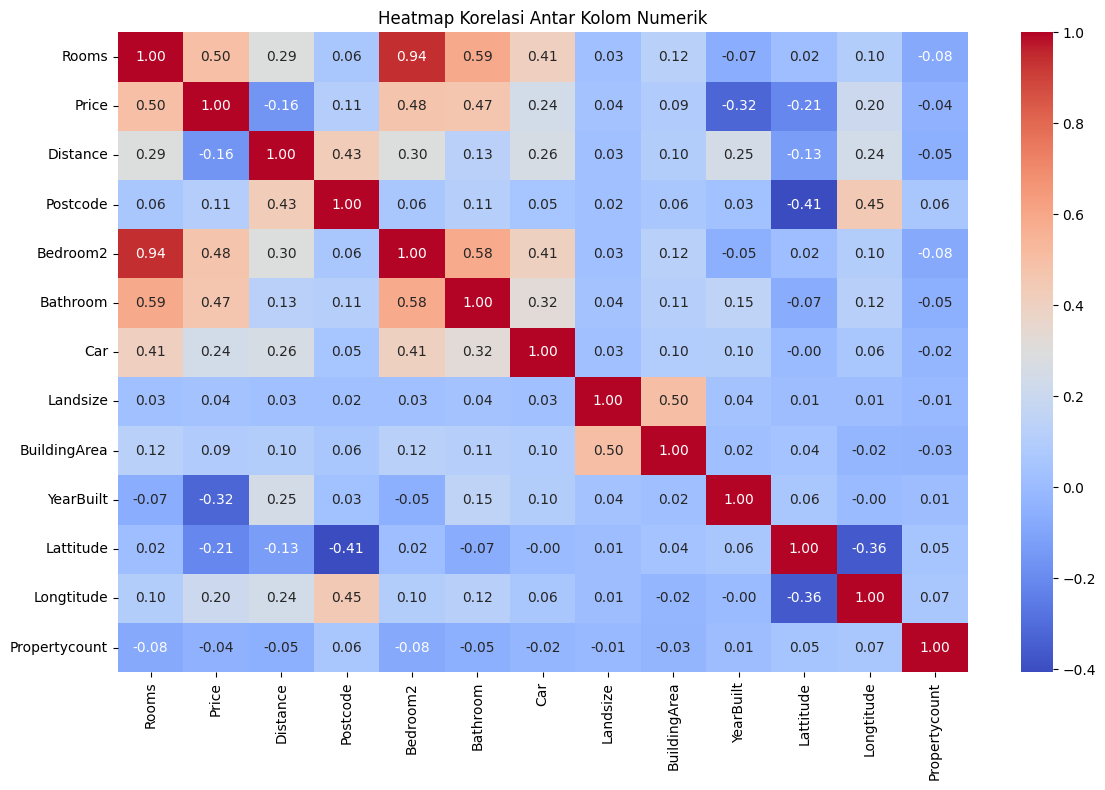


### 2. Scatter Plot Antar Kolom Numerik dengan Variabel Kategorikal ###


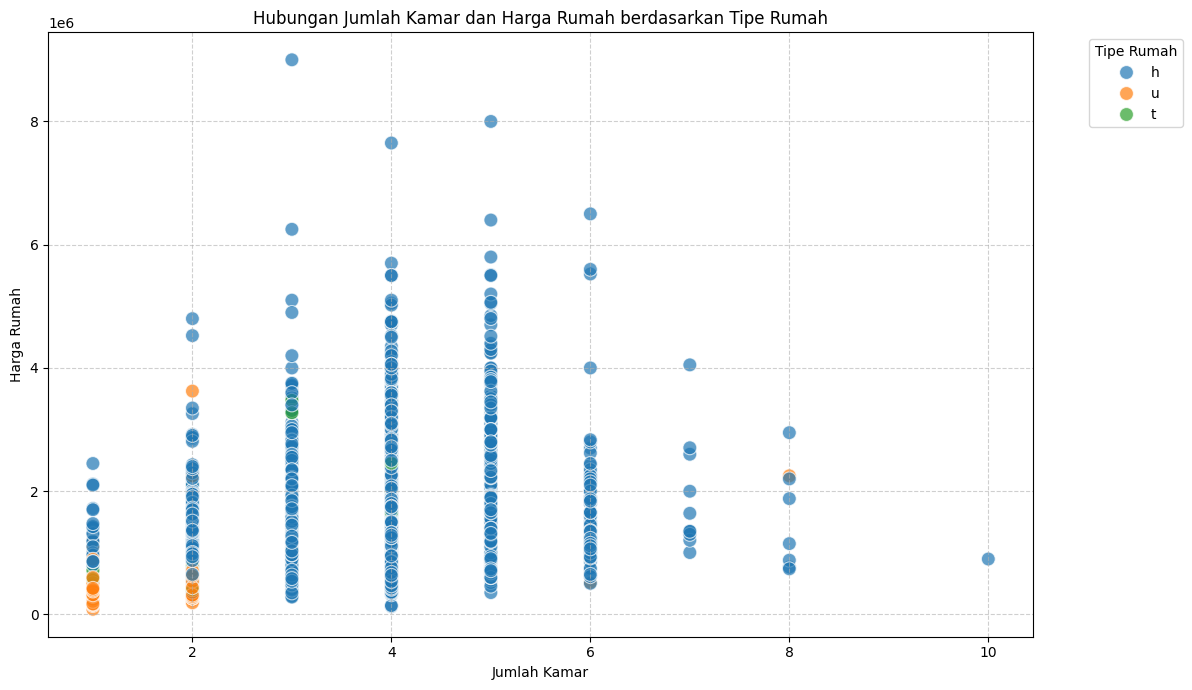

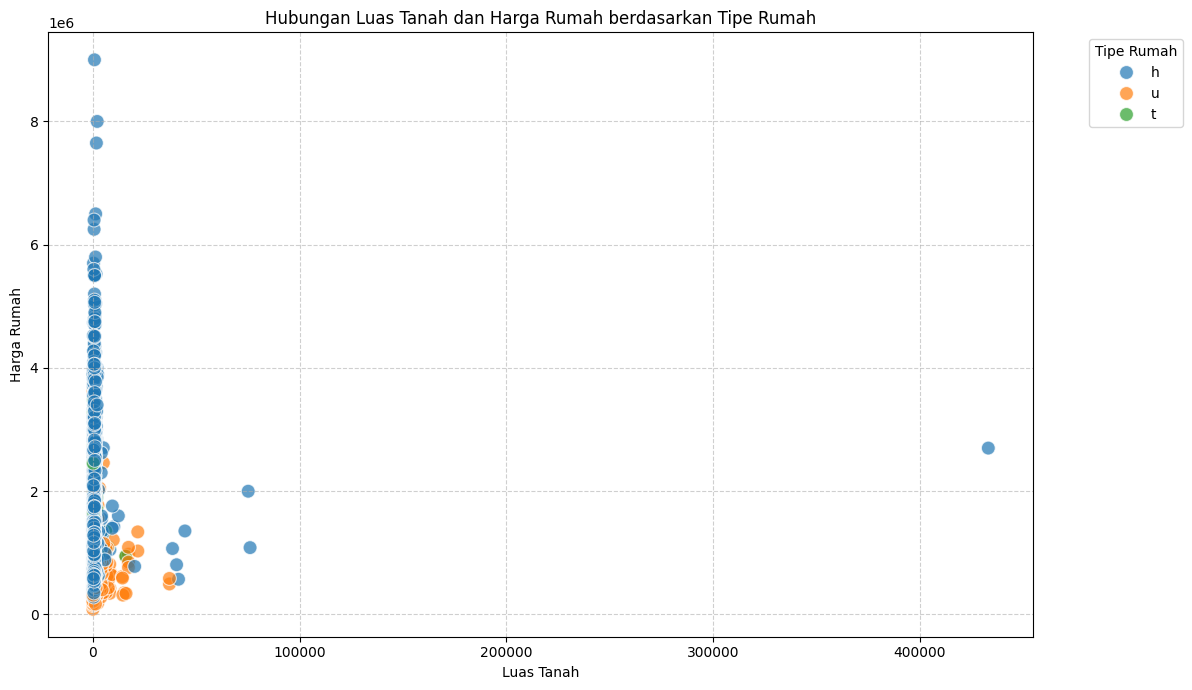


### 3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori ###


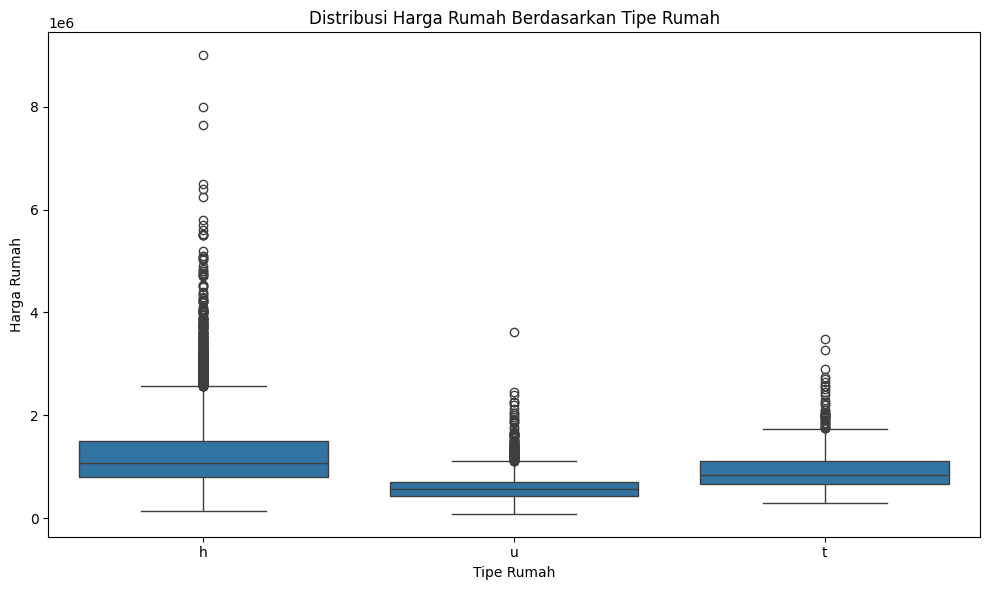

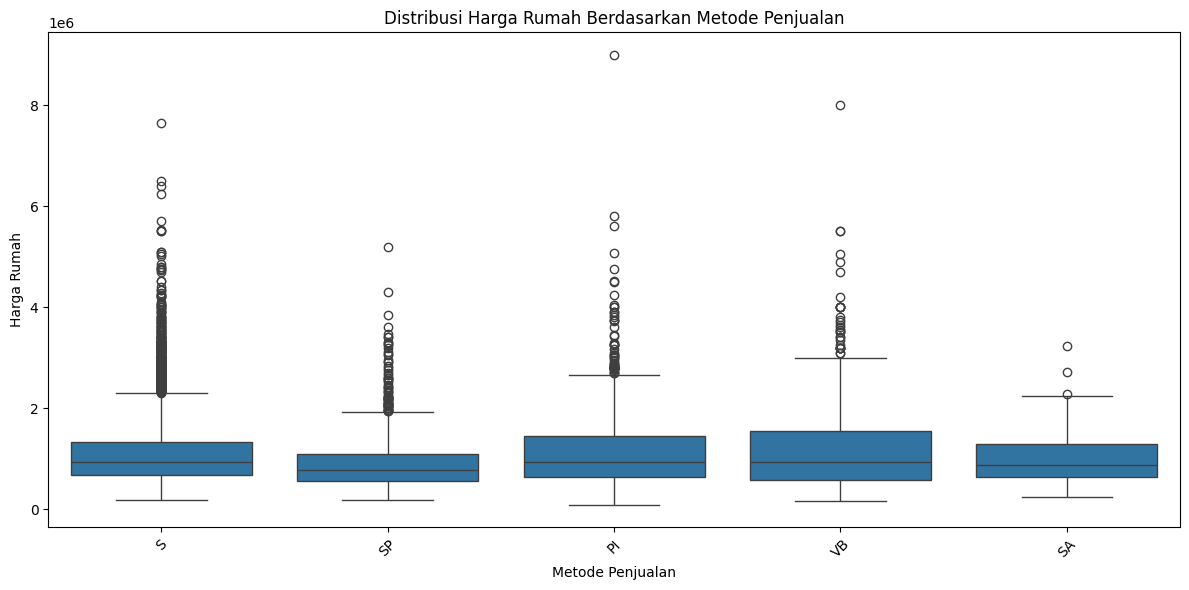

In [18]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()
print("### 1. Heatmap Korelasi Antar Kolom Numerik ###")
plt.figure(figsize=(12, 8))
correlation_matrix = df[kolom_numerik].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Heatmap Korelasi Antar Kolom Numerik')
plt.tight_layout()
plt.show()
print("\n### 2. Scatter Plot Antar Kolom Numerik dengan Variabel Kategorikal ###")

# Scatter Plot 1: Jumlah kamar vs harga berdasarkan tipe rumah
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='Rooms',
    y='Price',
    hue='Type',
    s=100,
    alpha=0.7
)
plt.title('Hubungan Jumlah Kamar dan Harga Rumah berdasarkan Tipe Rumah')
plt.xlabel('Jumlah Kamar')
plt.ylabel('Harga Rumah')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Tipe Rumah', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatter Plot 2: Luas tanah vs harga berdasarkan tipe rumah
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='Landsize',
    y='Price',
    hue='Type',
    s=100,
    alpha=0.7
)
plt.title('Hubungan Luas Tanah dan Harga Rumah berdasarkan Tipe Rumah')
plt.xlabel('Luas Tanah')
plt.ylabel('Harga Rumah')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Tipe Rumah', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("\n### 3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori ###")

# Boxplot harga berdasarkan tipe rumah
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Type',
    y='Price'
)
plt.title('Distribusi Harga Rumah Berdasarkan Tipe Rumah')
plt.xlabel('Tipe Rumah')
plt.ylabel('Harga Rumah')
plt.tight_layout()
plt.show()

# Boxplot harga berdasarkan metode penjualan
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='Method',
    y='Price'
)
plt.title('Distribusi Harga Rumah Berdasarkan Metode Penjualan')
plt.xlabel('Metode Penjualan')
plt.ylabel('Harga Rumah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Ringkasan Hasil Analisis Bivariat & Multivariat**

Setelah dilakukan analisis bivariat dan multivariat pada dataset Melbourne Housing, diperoleh beberapa temuan mengenai hubungan antarvariabel numerik maupun perbedaan harga berdasarkan variabel kategorikal.

1. Heatmap Korelasi Antar Kolom Numerik

  Heatmap korelasi digunakan untuk melihat hubungan antarvariabel numerik dalam dataset.

* Terdapat hubungan positif antara Rooms dan Price, yang menunjukkan bahwa properti dengan jumlah kamar lebih banyak cenderung memiliki harga yang lebih tinggi.
* Korelasi antara Rooms dan Price berada di sekitar 0,50, yang menunjukkan hubungan positif dengan kekuatan sedang.
* Beberapa variabel lain juga memiliki hubungan satu sama lain, sehingga heatmap dapat digunakan sebagai dasar untuk menentukan variabel yang berpotensi digunakan dalam pemodelan regresi.
* Variabel yang memiliki korelasi rendah terhadap Price tetap tidak secara otomatis harus dihapus karena hubungan antarvariabel perlu dipertimbangkan bersama konteks data dan hasil analisis lainnya.

2. Scatter Plot Rooms vs Price dan Landsize vs Price

* Rooms vs Price: Scatter plot menunjukkan kecenderungan hubungan positif. Secara umum, semakin banyak jumlah kamar, harga properti cenderung meningkat. Namun, titik data cukup menyebar sehingga hubungan tersebut tidak bersifat sempurna.
* Landsize vs Price: Hubungan antara luas tanah dan harga terlihat lebih tersebar. Terdapat beberapa properti dengan luas tanah yang sangat besar sehingga menghasilkan titik ekstrem (outlier).
* Kedua scatter plot menunjukkan bahwa harga properti dipengaruhi oleh lebih dari satu karakteristik. Oleh karena itu, penggunaan beberapa variabel prediktor dalam model regresi dapat dipertimbangkan.

3. Boxplot Price Berdasarkan Type

Boxplot digunakan untuk membandingkan distribusi harga berdasarkan tipe properti.

* Terdapat perbedaan distribusi harga antar tipe properti.
* Tipe h (house) terlihat memiliki distribusi dan median harga yang relatif lebih tinggi dibandingkan beberapa tipe lainnya.
Terdapat pula beberapa outlier harga tinggi pada masing-masing tipe properti.
* Hal ini menunjukkan bahwa jenis properti (Type) berpotensi memiliki hubungan dengan harga (Price) dan dapat dipertimbangkan dalam analisis lebih lanjut.

4. Boxplot Price Berdasarkan Method

Boxplot berdasarkan metode penjualan menunjukkan bahwa distribusi harga berbeda antar kategori Method.

* Setiap metode penjualan memiliki sebaran harga yang berbeda.
* Terdapat beberapa nilai harga ekstrem (outlier) pada kategori tertentu.
* Perbedaan distribusi tersebut menunjukkan bahwa metode penjualan dapat memiliki hubungan dengan karakteristik harga properti, meskipun hubungan tersebut perlu dianalisis lebih lanjut untuk mengetahui pengaruhnya terhadap Price.

Kesimpulan Analisis Bivariat & Multivariat

Secara keseluruhan, hasil analisis menunjukkan adanya hubungan antara karakteristik properti dengan harga (Price). Jumlah kamar (Rooms) menunjukkan hubungan positif dengan harga, sedangkan luas tanah (Landsize) memiliki pola yang lebih menyebar dan mengandung beberapa nilai ekstrem. Selain itu, terdapat perbedaan distribusi harga berdasarkan tipe properti (Type) dan metode penjualan (Method).

Hasil analisis ini dapat menjadi dasar untuk menentukan variabel yang akan digunakan pada tahap data preprocessing dan pemodelan regresi linear. Sebelum membangun model, missing values yang ditemukan pada tahap sebelumnya juga perlu ditangani terlebih dahulu.

### **Langkah Selanjutnya**
* Data Preprocessing: Missing values yang ditemukan pada tahap EDA, khususnya pada variabel Car, BuildingArea, YearBuilt, dan CouncilArea, akan ditangani menggunakan metode yang sesuai berdasarkan karakteristik masing-masing variabel.
* Pemilihan Variabel: Berdasarkan hasil EDA, variabel yang memiliki keterkaitan dengan Price, seperti Rooms, Distance, Landsize, BuildingArea, dan Bathroom, dapat dipertimbangkan sebagai variabel prediktor. Price digunakan sebagai variabel target.
* Encoding Variabel Kategorikal: Variabel kategorikal yang digunakan dalam model, seperti Type, Method, dan Regionname, akan dikonversi ke bentuk numerik menggunakan metode encoding yang sesuai.
* Pembagian Data: Dataset akan dibagi menjadi data training dan testing untuk digunakan dalam proses pembangunan dan pengujian model.
* Pemodelan Regresi Linear: Setelah preprocessing selesai, model regresi linear akan dibangun untuk memprediksi Price berdasarkan variabel-variabel prediktor yang telah dipilih.
* Evaluasi Model: Performa model akan dievaluasi menggunakan metrik R², MAE, dan RMSE untuk mengetahui kemampuan model dalam memprediksi harga properti.

### **2. Tahap Preprocessing**

**Step 1 - Pemeriksaan Data**

In [32]:
print("Tipe data Date sebelum cleaning:")
print(df['Date'].dtype)

print("\nContoh data Date:")
print(df['Date'].head())

Tipe data Date sebelum cleaning:
object

Contoh data Date:
0    3/12/2016
1    4/02/2016
2    4/03/2017
3    4/03/2017
4    4/06/2016
Name: Date, dtype: object


ada tahap ini dilakukan pemeriksaan terhadap variabel Date untuk mengetahui tipe data dan contoh nilai yang terdapat di dalamnya. Pemeriksaan ini dilakukan sebagai bagian dari persiapan data sebelum menentukan variabel yang akan digunakan dalam pemodelan.

**Step 2 — Pemeriksaan Missing Value pada Date**

In [33]:
print("Tipe data Date setelah cleaning:")
print(df['Date'].dtype)

print("\nJumlah missing pada Date:")
print(df['Date'].isnull().sum())

Tipe data Date setelah cleaning:
object

Jumlah missing pada Date:
0


Pemeriksaan dilakukan untuk mengetahui apakah terdapat missing value pada variabel Date. Selain itu, tipe data Date diperiksa kembali. Pada tahap ini belum dilakukan transformasi atau pembersihan khusus terhadap tanggal karena variabel Date nantinya tidak digunakan dalam model.

**Step 3 — Pemeriksaan Variabel Kategorikal**

In [34]:
kolom_kategorikal = df.select_dtypes(
    include=['object']
).columns.tolist()

print("### Jumlah Kategori Unik ###")

for kolom in kolom_kategorikal:
    print(f"{kolom}: {df[kolom].nunique()}")

### Jumlah Kategori Unik ###
Suburb: 314
Address: 13378
Type: 3
Method: 5
SellerG: 268
Date: 58
CouncilArea: 33
Regionname: 8


In [35]:
for kolom in kolom_kategorikal:
    print(f"\n### {kolom} ###")
    print(df[kolom].value_counts().head(20))


### Suburb ###
Suburb
Reservoir         359
Richmond          260
Bentleigh East    249
Preston           239
Brunswick         222
Essendon          220
South Yarra       202
Glen Iris         195
Hawthorn          191
Coburg            190
Northcote         188
Brighton          186
Kew               177
Pascoe Vale       171
Balwyn North      171
Yarraville        164
St Kilda          162
Glenroy           159
Port Melbourne    153
Moonee Ponds      149
Name: count, dtype: int64

### Address ###
Address
5 Margaret St       3
13 Robinson St      3
2 Bruce St          3
36 Aberfeldie St    3
14 Arthur St        3
1/1 Clarendon St    3
28 Blair St         3
53 William St       3
5 Charles St        3
66 Palmerston St    2
406/152 Sturt St    2
249 Punt Rd         2
6 Hamilton St       2
1 Bellarine St      2
33 McCarron Pde     2
6 Chester St        2
2/17 Greene St      2
47 Clifton St       2
28 Guildford Rd     2
36 Belford Rd       2
Name: count, dtype: int64

### Type ###
Type
h

Pada tahap ini dilakukan pemeriksaan terhadap variabel kategorikal dengan melihat jumlah kategori unik dan frekuensi masing-masing kategori. Pemeriksaan ini diperlukan untuk mengetahui karakteristik setiap variabel kategorikal sebelum dilakukan proses encoding.

Hasil pemeriksaan juga menunjukkan bahwa beberapa variabel memiliki jumlah kategori yang cukup banyak, terutama Suburb, Address, dan SellerG. Jumlah kategori tersebut perlu dipertimbangkan karena dapat menghasilkan jumlah fitur yang besar ketika dilakukan One-Hot Encoding.

**Step 4 — Penanganan Missing Value**

In [36]:
# imputasi missing value
df['Car'] = df['Car'].fillna(
    df['Car'].median()
)
df['YearBuilt'] = df['YearBuilt'].fillna(
    df['YearBuilt'].median()
)
df['CouncilArea'] = df['CouncilArea'].fillna(
    'Unknown'
)
df['BuildingArea'] = df['BuildingArea'].fillna(
    df['BuildingArea'].median()
)

Berdasarkan hasil EDA, terdapat missing value pada variabel Car, BuildingArea, YearBuilt, dan CouncilArea.

Missing value pada Car, YearBuilt, dan BuildingArea ditangani menggunakan nilai median karena ketiga variabel tersebut merupakan variabel numerik. Median digunakan agar pengisian nilai tidak terlalu dipengaruhi oleh nilai ekstrem yang terdapat pada data.

Sementara itu, missing value pada CouncilArea diisi dengan kategori Unknown karena variabel tersebut merupakan variabel kategorikal. Dengan demikian, data yang sebelumnya kosong tetap dipertahankan sebagai kategori tersendiri.

**Step 5 — Pemeriksaan Missing Value Setelah Imputasi**

In [37]:
print("### Missing Value Setelah Imputasi ###")

missing_setelah = df.isnull().sum()

print(missing_setelah[missing_setelah > 0])

### Missing Value Setelah Imputasi ###
Series([], dtype: int64)


Setelah proses imputasi dilakukan, dilakukan pemeriksaan ulang untuk memastikan apakah masih terdapat missing value pada dataset. Pemeriksaan ini bertujuan memastikan bahwa missing value yang ditemukan pada tahap EDA telah ditangani sebelum data digunakan untuk pemodelan.

Kalau output-nya kosong, bisa ditambahkan:

Berdasarkan hasil pemeriksaan, tidak terdapat lagi missing value pada variabel yang sebelumnya memiliki data kosong.

**Step 6 - Menentukan Target dan Fitur**

In [38]:
# Target
y = df['Price']

# Fitur
X = df.drop(columns=['Price'])

print("Target (y):", y.name)
print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])

Target (y): Price
Jumlah fitur: 20
Jumlah data: 13580


Pada penelitian ini, Price ditetapkan sebagai variabel target (y) karena tujuan utama model adalah memprediksi harga properti. Seluruh variabel selain Price digunakan sebagai variabel fitur (X) yang menjadi dasar untuk melakukan prediksi harga rumah.

**Step 7 — Identifikasi Fitur Numerik dan Kategorikal**

In [39]:
fitur_numerik = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

fitur_kategorikal = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Fitur Numerik:")
print(fitur_numerik)

print("\nFitur Kategorikal:")
print(fitur_kategorikal)

Fitur Numerik:
['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']

Fitur Kategorikal:
['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']


Fitur pada dataset dipisahkan menjadi fitur numerik dan kategorikal berdasarkan tipe datanya. Fitur numerik dapat digunakan dalam bentuk numerik, sedangkan fitur kategorikal perlu dikonversi menjadi bentuk numerik agar dapat digunakan oleh model Linear Regression.

**Step 8 — Menghapus Variabel Date**

In [40]:
X = X.drop(columns=['Date'], errors='ignore')

Variabel Date dihapus dari fitur karena pada penelitian ini informasi tanggal tidak digunakan sebagai variabel prediktor dan tidak dilakukan proses ekstraksi fitur seperti tahun, bulan, atau hari. Oleh karena itu, variabel tersebut tidak digunakan dalam pemodelan.

**Step 9 — Menghapus Variabel Address**

In [41]:
X = X.drop(columns=['Address'], errors='ignore')

Variabel Address dihapus karena memiliki jumlah kategori yang sangat tinggi. Jika langsung dilakukan One-Hot Encoding, variabel ini dapat menghasilkan jumlah fitur yang sangat banyak dan membuat model menjadi lebih kompleks.

Informasi mengenai lokasi properti masih dapat direpresentasikan melalui variabel lain seperti Suburb, CouncilArea, Regionname, Distance, Latitude, dan Longitude.

**Step 10 — One-Hot Encoding**

In [42]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Ukuran X setelah encoding:")
print(X.shape)

print("\n5 data pertama:")
print(X.head())

Ukuran X setelah encoding:
(13580, 638)

5 data pertama:
   Rooms  Distance  Postcode  Bedroom2  Bathroom  Car  Landsize  BuildingArea  \
0      2       2.5    3067.0       2.0       1.0  1.0     202.0         126.0   
1      2       2.5    3067.0       2.0       1.0  0.0     156.0          79.0   
2      3       2.5    3067.0       3.0       2.0  0.0     134.0         150.0   
3      3       2.5    3067.0       3.0       2.0  1.0      94.0         126.0   
4      4       2.5    3067.0       3.0       1.0  2.0     120.0         142.0   

   YearBuilt  Lattitude  ...  CouncilArea_Wyndham  CouncilArea_Yarra  \
0     1970.0   -37.7996  ...                False               True   
1     1900.0   -37.8079  ...                False               True   
2     1900.0   -37.8093  ...                False               True   
3     1970.0   -37.7969  ...                False               True   
4     2014.0   -37.8072  ...                False               True   

   CouncilArea_Yarra Ra

Variabel kategorikal yang masih berbentuk teks dikonversi menjadi variabel numerik menggunakan One-Hot Encoding. Parameter drop_first=True digunakan untuk menghilangkan satu kategori pada setiap variabel sebagai kategori referensi sehingga mengurangi redundansi fitur.

Setelah proses encoding, dilakukan pemeriksaan ukuran X dan beberapa baris pertama untuk memastikan proses transformasi berhasil.

**Step 11 — Pemeriksaan Tipe Data**

In [43]:
print(X.dtypes.value_counts())

bool       626
float64     11
int64        1
Name: count, dtype: int64


Setelah proses encoding, dilakukan pemeriksaan terhadap tipe data pada fitur X. Pemeriksaan ini bertujuan memastikan data telah berada dalam format yang sesuai untuk digunakan pada tahap pemodelan Linear Regression.

**Step 12 — Pemeriksaan Missing Value pada Fitur**

In [44]:
print("\nMissing value pada X:")
print(X.isnull().sum()[X.isnull().sum() > 0])


Missing value pada X:
Series([], dtype: int64)


Pemeriksaan missing value kembali dilakukan pada fitur X setelah proses encoding. Hal ini bertujuan memastikan tidak terdapat nilai kosong yang dapat mengganggu proses pelatihan model.

Kalau output kosong:

Tidak terdapat missing value pada fitur X, sehingga fitur siap digunakan untuk pembagian data training dan testing.

**Step 13 — Pemeriksaan Target Price**

In [45]:
print("Missing Price:", y.isnull().sum())

print("\nStatistik Price:")
print(y.describe())

Missing Price: 0

Statistik Price:
count    1.358000e+04
mean     1.075684e+06
std      6.393107e+05
min      8.500000e+04
25%      6.500000e+05
50%      9.030000e+05
75%      1.330000e+06
max      9.000000e+06
Name: Price, dtype: float64


Variabel target Price diperiksa untuk memastikan tidak terdapat missing value. Statistik deskriptif Price juga ditampilkan untuk melihat kembali karakteristik nilai target sebelum dilakukan pemodelan.

**Step 14 — Pembagian Data Training dan Testing**

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (10864, 638)
X_test : (2716, 638)
y_train: (10864,)
y_test : (2716,)


Dataset dibagi menjadi data training dan data testing menggunakan train_test_split. Sebanyak 80% data digunakan sebagai data training dan 20% sebagai data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengukur kemampuan model dalam melakukan prediksi terhadap data yang belum digunakan selama proses pelatihan.

random_state=42 digunakan agar pembagian data tetap konsisten ketika kode dijalankan kembali.

### **3. Tahap Regresi**

**Step 1 — Membuat dan Melatih Model Linear Regression**

In [48]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model berhasil dilatih.")

Model berhasil dilatih.


Pada tahap ini digunakan algoritma Linear Regression untuk membangun model prediksi harga rumah. Model dilatih menggunakan data training (X_train dan y_train). Proses pelatihan bertujuan untuk mempelajari hubungan antara fitur-fitur properti dengan variabel target Price.

Setelah proses fit() dijalankan, model telah mempelajari pola dari data training dan siap digunakan untuk melakukan prediksi pada data testing.

**Step 2 — Melakukan Prediksi**

In [49]:
# prediksi price
y_pred = model.predict(X_test)

print("10 hasil prediksi pertama:")
print(y_pred[:10])

10 hasil prediksi pertama:
[2136355.34811824  706350.47498859  921863.91616622  663842.14035542
  727131.59752531  732836.76995057  405213.88925323 1861282.08087484
  510086.67261373 1617266.31084073]


Setelah model berhasil dilatih, model digunakan untuk memprediksi harga rumah pada data testing (X_test). Hasil prediksi disimpan dalam variabel y_pred.

Sepuluh hasil prediksi pertama ditampilkan sebagai gambaran awal mengenai nilai Price yang diperkirakan oleh model.

### **4. Tahap Evaluasi Model**

**Step 1 — Membandingkan Harga Aktual dan Harga Prediksi**

In [50]:
hasil_prediksi = pd.DataFrame({
    'Price_Aktual': y_test.values,
    'Price_Prediksi': y_pred
})

print(hasil_prediksi.head(10))

   Price_Aktual  Price_Prediksi
0     2600000.0    2.136355e+06
1      620000.0    7.063505e+05
2     1000000.0    9.218639e+05
3      430000.0    6.638421e+05
4      392250.0    7.271316e+05
5      700000.0    7.328368e+05
6      439000.0    4.052139e+05
7     2236000.0    1.861282e+06
8      671000.0    5.100867e+05
9     1870000.0    1.617266e+06


Hasil prediksi dibandingkan dengan nilai Price aktual pada data testing. Perbandingan ini digunakan untuk melihat perbedaan antara harga sebenarnya dengan harga yang diprediksi oleh model.

Data aktual dan prediksi ditampilkan dalam bentuk DataFrame agar perbedaannya dapat diamati secara langsung.

**Step 2 — Evaluasi Menggunakan MAE**

In [51]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 233169.1642471555


Mean Absolute Error (MAE) digunakan untuk mengukur rata-rata besar kesalahan absolut antara harga aktual dan harga hasil prediksi.

Nilai MAE menunjukkan rata-rata selisih prediksi model terhadap harga aktual. Semakin kecil nilai MAE, semakin kecil rata-rata kesalahan prediksi model.

**Step 3 — Evaluasi Menggunakan MSE**

In [52]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 122157066053.2701


Mean Squared Error (MSE) digunakan untuk mengukur rata-rata kuadrat kesalahan antara nilai aktual dan nilai prediksi.

Karena kesalahan dikuadratkan, kesalahan prediksi yang besar akan memberikan pengaruh yang lebih besar terhadap nilai MSE. Semakin kecil nilai MSE, semakin baik hasil prediksi model.

**Step 4 — Evaluasi Menggunakan RMSE**

In [53]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 349509.75101314427


Root Mean Squared Error (RMSE) diperoleh dengan menghitung akar kuadrat dari MSE. RMSE digunakan untuk melihat besarnya rata-rata kesalahan prediksi dalam satuan yang sama dengan variabel target, yaitu Price.

Semakin kecil nilai RMSE, semakin kecil kesalahan prediksi model.

**Step 5 — Evaluasi Menggunakan R²**

In [54]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.6924652430731016


R² (R-squared) digunakan untuk melihat seberapa besar variasi pada Price yang dapat dijelaskan oleh model berdasarkan fitur-fitur yang digunakan.

Nilai R² yang semakin mendekati 1 menunjukkan bahwa model mampu menjelaskan variasi harga dengan lebih baik. Nilai R² perlu dilihat bersama metrik lainnya agar penilaian performa model tidak hanya berdasarkan satu ukuran.

**Step 6 — Ringkasan Hasil Evaluasi**

In [55]:
print("=== HASIL EVALUASI MODEL ===")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

=== HASIL EVALUASI MODEL ===
MAE  : 233,169.16
MSE  : 122,157,066,053.27
RMSE : 349,509.75
R²   : 0.6925


Hasil evaluasi model dirangkum menggunakan empat metrik, yaitu MAE, MSE, RMSE, dan R². MAE, MSE, dan RMSE digunakan untuk melihat besarnya kesalahan prediksi, sedangkan R² digunakan untuk melihat kemampuan model dalam menjelaskan variasi Price.

Hasil dari keempat metrik tersebut digunakan secara bersama-sama untuk menilai perfor

**Step 7 — Visualisasi Price Aktual vs Price Prediksi**

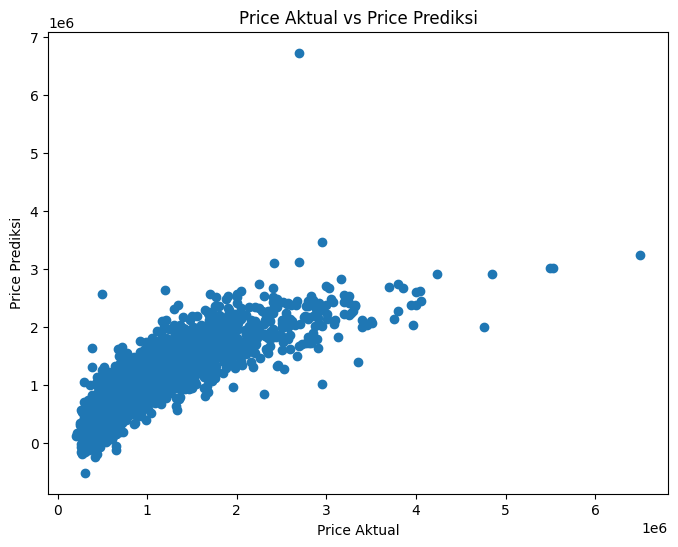

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Price Aktual')
plt.ylabel('Price Prediksi')
plt.title('Price Aktual vs Price Prediksi')

plt.show()

Grafik digunakan untuk melihat hubungan antara Price aktual dan Price hasil prediksi model. Setiap titik menunjukkan perbandingan antara harga aktual dengan harga yang diprediksi untuk data testing.

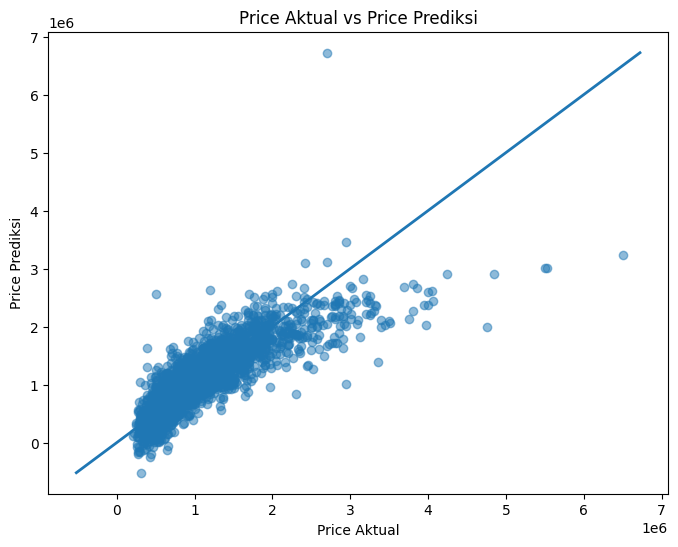

In [57]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Titik data aktual vs prediksi
plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

# Garis referensi/prediksi sempurna
nilai_min = min(y_test.min(), y_pred.min())
nilai_max = max(y_test.max(), y_pred.max())

plt.plot(
    [nilai_min, nilai_max],
    [nilai_min, nilai_max],
    linewidth=2
)

plt.xlabel('Price Aktual')
plt.ylabel('Price Prediksi')
plt.title('Price Aktual vs Price Prediksi')

plt.show()

Grafik menunjukkan hubungan antara Price aktual dan Price hasil prediksi pada data testing. Garis diagonal pada grafik digunakan sebagai garis referensi yang menggambarkan kondisi ketika nilai prediksi sama dengan nilai aktual.

Titik yang berada semakin dekat dengan garis menunjukkan prediksi yang semakin mendekati harga aktual. Sebaliknya, titik yang semakin jauh dari garis menunjukkan adanya kesalahan prediksi yang lebih besar.

Grafik ini digunakan sebagai visualisasi tambahan untuk melihat seberapa dekat hasil prediksi model terhadap nilai aktual.